In [1]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)
library(ggplot2)
library(ggrepel)
options(repr.matrix.max.rows=10, repr.matrix.max.cols=50)
devtools::load_all('utils/modules/R/gwastools')

i Loading gwastools

Loading required package: stringr

Warning message in setup_ns_exports(path, export_all, export_imports):
"Objects listed as exports, but not present in namespace: summarize_bcftools_trio_stats"


In [49]:
f <- list.files('data/saige/output/binary/step2/', full.names = TRUE, pattern = ".txt.gz")

In [50]:
#d <- readLines(f[1])[1]

In [51]:
#strsplit(d, split = '\t')

#d <- fread('data/saige/output/binary/step2//ukb_eur_wes_200k_maf0to5e-2_IBD_combined_pLoF_damaging_missense.txt.gz')

In [122]:
d <- fread(f[20])
head(d[order(d$p.value)])
bridge[bridge$ensembl_gene_id %in% "ENSG00000064270",]

Warning message in fread(f[20]):
"Detected 21 column names but the data has 19 columns. Filling rows automatically. Set fill=TRUE explicitly to avoid this warning."


CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,Tstat,var,p.value,p.value.NA,Is.SPA,p.value.NA_c,Is.SPA.converge,AF_case,AF_ctrl,N_case,N_ctrl
<chr>,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<int>,<int>,<lgl>,<lgl>
chr16,1,ENSG00000064270,0,1,42,1.18917e-04,0,2.22307,0.470260,15.63400,7.03262,2.27503e-06,3.73827e-09,TRUE,0.000515225,6.99812e-05,19409,157185,NA,NA
chr11,1,ENSG00000156603,0,1,36,1.01929e-04,0,1.71922,0.447981,11.97700,6.96651,1.24188e-04,5.68606e-06,TRUE,0.000412180,6.36193e-05,19409,157185,NA,NA
chr15,1,ENSG00000104043,0,1,14,3.96389e-05,0,2.34242,0.731449,6.43246,2.74608,1.36272e-03,1.03734e-04,TRUE,0.000206090,1.90858e-05,19409,157185,NA,NA
chr2,1,ENSG00000163331,0,1,14,3.96389e-05,0,2.19241,0.701290,6.34174,2.89259,1.77053e-03,1.92423e-04,TRUE,0.000206090,1.90858e-05,19409,157185,NA,NA
chr17,1,ENSG00000108839,0,1,19,5.37957e-05,0,2.24473,0.719290,6.35222,2.82984,1.80385e-03,1.59296e-04,TRUE,0.000206090,3.49906e-05,19409,157185,NA,NA
chr17,1,ENSG00000196689,0,1,8,2.26508e-05,0,2.85898,0.932446,4.99394,1.74675,2.16862e-03,1.57731e-04,TRUE,0.000154567,6.36193e-06,19409,157185,NA,NA


ensembl_gene_id,hgnc_symbol
<chr>,<chr>
ENSG00000064270,ATP2C2


In [95]:
get_qq_ribbon <- function(observed_p, conf_level = 0.95, na.rm = FALSE){
    stopifnot(is.numeric(observed_p))
    stopifnot(any(observed_p >= 0))
    n <- length(observed_p)
    observed_rank <- rank(observed_p)
    dt <- data.table(
        clower = -log10(qbeta(p = (1 - conf_level) / 2, shape2 = n:1, shape1 = 1:n)),
        cupper = -log10(qbeta(p = (1 + conf_level) / 2, shape2 = n:1, shape1 = 1:n))
    )
    dt <- dt[observed_rank, ]
    return(dt)
}

In [96]:
dt[5,]

pvalue.observed,pvalue.expected,clower,cupper
<dbl>,<dbl>,<dbl>,<dbl>
2.7438,2.463893,2.95176,2.153129


In [114]:
bridge <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')[,1:2]

CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,Tstat,var,p.value,p.value.NA,Is.SPA,p.value.NA_c,Is.SPA.converge,AF_case,AF_ctrl,N_case,N_ctrl,p.value.expt
<chr>,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<int>,<int>,<lgl>,<lgl>,<dbl>
chr1,1,ENSG00000132781,0,1,62,1.75544e-04,0,10.73640,1.53195,19.06440,1.775680,2.41210e-12,1.98651e-46,TRUE,0.002796420,1.21375e-04,3576,173018,NA,NA,0.0006872852
chr4,1,ENSG00000138735,0,1,5,1.41568e-05,0,17.51550,4.56812,3.87393,0.221172,1.25931e-04,1.76087e-16,TRUE,0.000559284,2.88987e-06,3576,173018,NA,NA,0.0013745704
chr12,1,ENSG00000183495,0,1,8,2.26508e-05,0,7.82297,2.38840,3.71756,0.475211,1.05515e-03,6.93660e-08,TRUE,0.000559284,1.15595e-05,3576,173018,NA,NA,0.0020618557
chr3,1,ENSG00000173200,0,1,6,1.69881e-05,0,14.88360,4.60718,2.87591,0.193226,1.23560e-03,6.05103e-11,TRUE,0.000419463,8.66962e-06,3576,173018,NA,NA,0.0027491409
chr19,1,ENSG00000007306,0,1,12,3.39762e-05,0,6.89104,2.22852,3.72076,0.539941,1.98672e-03,4.11441e-07,TRUE,0.000559284,2.31190e-05,3576,173018,NA,NA,0.0034364261
chr11,1,ENSG00000166833,0,1,17,4.81330e-05,0,5.97394,2.00706,3.67402,0.615007,2.91600e-03,2.80084e-06,TRUE,0.000559284,3.75683e-05,3576,173018,NA,NA,0.0041237113


[1] 5

Warning message:
"Removed 1449 rows containing missing values (geom_text_repel)."


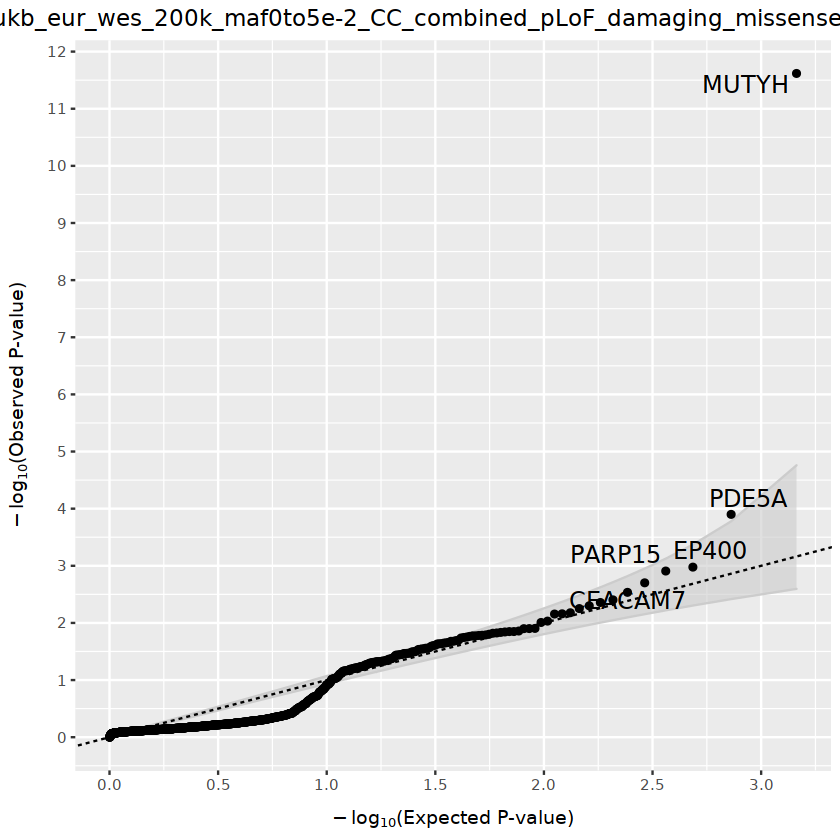

In [264]:
fd <- f[11]
d <- fread(fd, fill = TRUE)
d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
head(d[order(d$p.value)])


ribbon_p <- 0.95

n <- length(d$p.value)
dt <- data.table(
    ensembl_gene_id = d$MarkerID[order(d$p.value)],
    pvalue.observed = -log10(sort(d$p.value)),
    pvalue.expected = -log10(sort(d$p.value.expt)),
    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
)

#dt$ensembl_gene_id <- d$MarkerID[rev(dt$rank)]
top10quantile <- quantile(dt$pvalue.observed, 0.997)
dt <- merge(dt, bridge, all.x = TRUE)
dt$label <- dt$hgnc_symbol
dt$label[!(dt$pvalue.observed > dt$cupper & dt$pvalue.observed > top10quantile)] <- NA
sum(!is.na(dt$label))

ggplot(dt, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label)) +
    geom_ribbon(fill="grey80", color="grey80", alpha = 0.6) +
    geom_point() +
    geom_abline(linetype = 'dashed') + 
    geom_text_repel(color = 'black', size = 5, max.overlaps = Inf) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    ggtitle(basename(fd)) +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5))
    


Warning message:
"Removed 1446 rows containing missing values (geom_text_repel)."


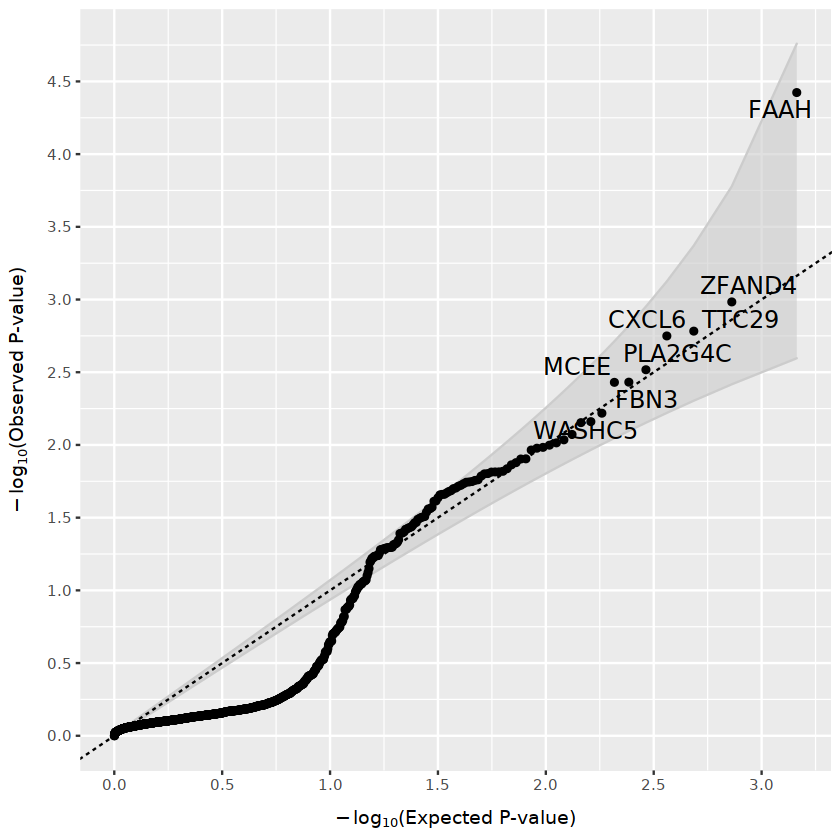

In [57]:
plot_saige_qq <- function(dt,
                          aes_main = aes(x=-log10(pvalue.expected), y = -log10(pvalue.observed), color = 'blue', label = NA),
                          aes_ribbon = aes(ymin=clower, ymax=cupper)){
    ggplot(dt, aes_main) +
            geom_ribbon(aes_ribbon, fill="grey80", color="grey80") +
            geom_point(size = 3) +
            geom_abline(linetype = 'dashed') +
            geom_text_repel(color = 'black', size = 5) +
            #labs(title=phenotype, color=paste0("key_label")) +
            scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
            scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
            xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
            ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
            #facet_wrap(~csqs_category) +
            theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
                  axis.title.y = element_text(margin=ggplot2::margin(r=10)),
                  plot.title = element_text(hjust=0.5))

}

In [113]:
sum(d$p.value < 0)

[1] 0

In [74]:
observed_p <- d$p.value[1:100]

In [99]:
stopifnot(is.numeric(observed_p))
NAs <- sum(is.na(observed_p))
n <- length(observed_p)
observed_rank <- rank(observed_p)
uniform <- (1:n)/(n+1)
uniform <- uniform[observed_rank]
return(uniform)



In [ ]:
get_expected_p <- function(observed_p, na.rm = FALSE){
    stopifnot(is.numeric(observed_p))
    stopifnot(any(observed_p >= 0))
    sum_na <- sum(is.na(observed_p))
    if (sum_na > 0){
           if (na.rm){
                observed_p <- observed_p[!is.na(observed_p)]
           } else {
                warning("NAs detected in P-values. Set na.rm = TRUE to remove them.")
           }
    }
    n <- length(observed_p)
    observed_rank <- rank(observed_p)
    uniform <- (1:n)/(n+1)
    uniform <- uniform[observed_rank]
    return(uniform)
}